<a href="https://colab.research.google.com/github/1FATIMAH1/IT362/blob/main/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IT 362 Data Science Project – Phase 2

## Primary Data Processing, Cleaning, and Descriptive Analysis

In this section, we will clean and prepare the primary SATEL real estate dataset collected in Phase 1. Then, we will use the cleaned data to calculate descriptive statistics and create visualizations to understand the data better.

### 1. Import Libraries

We first import the Python libraries needed to clean, analyze, and visualize the data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 2. Load the Primary Dataset

The primary dataset collected and prepared during Phase 1 is loaded from the CSV file. The dataset contains the annual residential rental properties selected from SATEL.

In [ ]:
df = pd.read_csv('riyadh_annual_rentals_collected-3.csv')

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Number of rows: 218
Number of columns: 14


,property_id,neighborhood,neighborhood_ar,property_type,annual_rent_sar,area_sqm,bedrooms,bathrooms,furnishing,status,title_text,created_at,source_url,collection_date
0,C0055,An Narjis,النرجس,Compounds,110000,139.0,3,4,Unfurnished,Available,Satel at Opal on Thoumamah Road - 3 Bedrooms A...,2026-04-06T14:15:09.408Z,https://apiv2.satel.sa/property/filter,2026-09-11
1,C0087,Al Olaya,العليا,Apartments,160000,112.0,2,3,Fully furnished,Available,Olaris More Than Just a Place to Live,2026-07-27T11:56:07.417Z,https://apiv2.satel.sa/property/filter,2026-09-11
2,A0177,An Narjis,النرجس,Compounds,140000,132.0,3,3,Fully furnished,Available,Satel at Opal — New Furnished & Unfurnished Ap...,2025-09-18T08:36:48.027Z,https://apiv2.satel.sa/property/filter,2026-09-11
3,C0052,Al Malaz,حي الملز,Compounds,73000,95.0,2,2,Fully furnished,Rented out,La Brise Community – Furnished 2 Beds with Bal...,2026-03-17T20:01:56.262Z,https://apiv2.satel.sa/property/filter,2026-09-11
4,C0084,An Nakheel,حي النخيل,Villas,370000,460.0,6,6,Partially furnished,Rented out,"Creative Community Where Comfort, Privacy, and...",2026-07-25T12:14:26.397Z,https://apiv2.satel.sa/property/filter,2026-09-11


In [ ]:
print(df.columns.tolist())

['property_id', 'neighborhood', 'neighborhood_ar', 'property_type', 'annual_rent_sar', 'area_sqm', 'bedrooms', 'bathrooms', 'furnishing', 'status', 'title_text', 'created_at', 'source_url', 'collection_date']


### 3. Initial Data Inspection

We first check the dataset structure, column names, and data types to better understand the data before cleaning.

In [ ]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
df.info()

Dataset shape: (218, 14)

Column names:
['property_id', 'neighborhood', 'neighborhood_ar', 'property_type', 'annual_rent_sar', 'area_sqm', 'bedrooms', 'bathrooms', 'furnishing', 'status', 'title_text', 'created_at', 'source_url', 'collection_date']

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_id      218 non-null    object 
 1   neighborhood     218 non-null    object 
 2   neighborhood_ar  201 non-null    object 
 3   property_type    218 non-null    object 
 4   annual_rent_sar  218 non-null    int64  
 5   area_sqm         218 non-null    float64
 6   bedrooms         218 non-null    int64  
 7   bathrooms        218 non-null    int64  
 8   furnishing       218 non-null    object 
 9   status           218 non-null    object 
 10  title_text       218 non-null    object 
 11  created_at       218 non-null 

### 4. Check for Missing Values

We check the dataset for missing values before cleaning. This helps us identify which columns have missing data and decide how they should be handled.

In [ ]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing_values)

Columns with missing values:
neighborhood_ar    17
dtype: int64


### 5. Check for Duplicate Records

We check for duplicate property IDs to make sure the same property is not counted more than once in the analysis.


In [ ]:
duplicate_ids = df['property_id'].duplicated().sum()

print("Duplicated property IDs:", duplicate_ids)

Duplicated property IDs: 0


### 6. Select Relevant Features

The dataset contains 14 columns. For the analysis, we select the features related to the property location, type, rental price, size, characteristics, and listing information. The source URL and collection date are not needed for the analysis, so they are excluded.

In [ ]:
selected_columns = [
    'property_id',
    'neighborhood',
    'neighborhood_ar',
    'property_type',
    'annual_rent_sar',
    'area_sqm',
    'bedrooms',
    'bathrooms',
    'furnishing',
    'status',
    'title_text',
    'created_at'
]

df = df[selected_columns].copy()

print("Dataset shape after selecting relevant features:", df.shape)
df.head()

Dataset shape after selecting relevant features: (218, 12)


,property_id,neighborhood,neighborhood_ar,property_type,annual_rent_sar,area_sqm,bedrooms,bathrooms,furnishing,status,title_text,created_at
0,C0055,An Narjis,النرجس,Compounds,110000,139.0,3,4,Unfurnished,Available,Satel at Opal on Thoumamah Road - 3 Bedrooms A...,2026-04-06T14:15:09.408Z
1,C0087,Al Olaya,العليا,Apartments,160000,112.0,2,3,Fully furnished,Available,Olaris More Than Just a Place to Live,2026-07-27T11:56:07.417Z
2,A0177,An Narjis,النرجس,Compounds,140000,132.0,3,3,Fully furnished,Available,Satel at Opal — New Furnished & Unfurnished Ap...,2025-09-18T08:36:48.027Z
3,C0052,Al Malaz,حي الملز,Compounds,73000,95.0,2,2,Fully furnished,Rented out,La Brise Community – Furnished 2 Beds with Bal...,2026-03-17T20:01:56.262Z
4,C0084,An Nakheel,حي النخيل,Villas,370000,460.0,6,6,Partially furnished,Rented out,"Creative Community Where Comfort, Privacy, and...",2026-07-25T12:14:26.397Z


### 7. Check Missing Values in Selected Features

After selecting the relevant features, we check for missing values again to see if any of the selected features need to be treated.

In [ ]:
missing_selected = df.isnull().sum()

print("Missing values in selected features:")
print(missing_selected)

Missing values in selected features:
property_id         0
neighborhood        0
neighborhood_ar    17
property_type       0
annual_rent_sar     0
area_sqm            0
bedrooms            0
bathrooms           0
furnishing          0
status              0
title_text          0
created_at          0
dtype: int64


**Finding:** The neighborhood_ar feature has 17 missing values. These records were kept because the neighborhood feature has no missing values and can still be used for the analysis. Therefore, no rows were removed.

### 8. Check and Correct Data Types

We check the data types of the selected features to make sure they are stored correctly. Numerical features should be numeric, while the listing creation date should be stored as a datetime.

In [ ]:
print(df.dtypes)

property_id         object
neighborhood        object
neighborhood_ar     object
property_type       object
annual_rent_sar      int64
area_sqm           float64
bedrooms             int64
bathrooms            int64
furnishing          object
status              object
title_text          object
created_at          object
dtype: object


### 9. Convert Date Variable

The `created_at` feature is stored as an object, so we convert it to a datetime data type to represent the listing dates correctly.

In [ ]:
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

print(df.dtypes)

property_id                     object
neighborhood                    object
neighborhood_ar                 object
property_type                   object
annual_rent_sar                  int64
area_sqm                       float64
bedrooms                         int64
bathrooms                        int64
furnishing                      object
status                          object
title_text                      object
created_at         datetime64[ns, UTC]
dtype: object


In [ ]:
print("Missing created_at values:", df['created_at'].isnull().sum())

Missing created_at values: 0


**Finding:** The created_at feature was successfully converted from an object to a datetime data type. The other selected features already had appropriate data types.

### 10. Check Numerical Values

We check the main numerical features for invalid or suspicious values, such as negative rental prices, zero or negative property areas, or unusual bedroom and bathroom values.

In [ ]:
numeric_columns = [
    'annual_rent_sar',
    'area_sqm',
    'bedrooms',
    'bathrooms'
]

df[numeric_columns].describe()

,annual_rent_sar,area_sqm,bedrooms,bathrooms
count,218.000000,218.000000,218.000000,218.000000
mean,121623.848624,151.094037,2.674312,3.073394
std,54589.760321,83.149380,0.905376,1.215919
min,50000.000000,0.000000,1.000000,1.000000
25%,85000.000000,110.000000,2.000000,2.000000
50%,110000.000000,129.000000,3.000000,3.000000
75%,140000.000000,154.750000,3.000000,3.000000
max,380000.000000,614.000000,7.000000,9.000000


**Finding:** The numerical features were checked for unusual values. Rental prices, bedrooms, and bathrooms have positive values. However, the minimum property area is 0 square meters, which is not a valid area and needs further investigation.

### 11. Investigate Invalid Area Values

The numerical summary shows that the minimum property area is 0 square meters. Since a property cannot have an area of zero, we check the affected record before deciding how to treat it.

In [ ]:
zero_area = df[df['area_sqm'] <= 0]

print("Number of listings with zero or negative area:", len(zero_area))

zero_area[[
    'property_id',
    'neighborhood',
    'property_type',
    'annual_rent_sar',
    'area_sqm',
    'bedrooms',
    'bathrooms',
    'title_text'
]]

Number of listings with zero or negative area: 1


,property_id,neighborhood,property_type,annual_rent_sar,area_sqm,bedrooms,bathrooms,title_text
36,C0099,Alyasmin,Floor,75000,0.0,3,4,3 Bedroom Floor for Rent in Al Yasmin | SATEL


**Finding:** One property has an area of 0 square meters. Since the other information for this property is still useful, the record will be kept and only the invalid area value will be treated as missing.

### 12. Treat Invalid Area Value

One listing has a property area of 0 square meters. Since the correct area is unknown, the value is changed to missing instead of estimating it. The listing is kept because its other information is still useful for the analysis.

In [ ]:
import numpy as np

df.loc[df['area_sqm'] <= 0, 'area_sqm'] = np.nan

print("Missing area values after treatment:", df['area_sqm'].isnull().sum())
print("Number of records:", len(df))

Missing area values after treatment: 1
Number of records: 218


**Finding:** The invalid area value was changed to missing, while the property record was kept. The dataset still contains 218 records, with one missing value in area_sqm.

### 13. Check Categorical Values

We check the categorical features for inconsistent names, spelling differences, or unexpected categories that could affect the analysis.

In [ ]:
categorical_columns = [
    'neighborhood',
    'property_type',
    'furnishing',
    'status'
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- neighborhood ---
neighborhood
Al Olaya                    40
An Narjis                   19
Al Malqa                    15
Al Wurud                    14
Al Aqiq                     12
Al Mathar Ash Shamali       12
An Nakheel                  12
Al Malaz                    10
Ar Rahmaniyyah               8
As Sulimaniyah               8
Al Mohammadiyyah             8
Alyasmin                     7
As Sahafah                   6
Hittin                       5
At Taawun                    5
Ar Rafiah                    4
Qurtubah                     4
King Salman Neighborhood     2
Al Ghadir                    2
Sedra                        2
Al Qirawan                   2
Al Murabba                   2
Al Muruj                     2
Al Aarid                     2
Almasiaf                     1
Irqah                        1
King Fahd                    1
Jarir                        1
Ar Rawdah                    1
Al Wadi                      1
An Nada                      1
An N

### 14. Standardize Neighborhood Names

The neighborhood names are checked for different spellings and formats. Some neighborhoods appear more than once because they are written differently or in Arabic. These values are standardized so that each neighborhood is treated as one category during the analysis.

In [ ]:
df['neighborhood'] = df['neighborhood'].replace({
    'Al-Aqiq': 'Al Aqiq',
    'Aarid': 'Al Aarid',
    'حي الملز': 'Al Malaz',
    'حي الملقا': 'Al Malqa'
})

print(df['neighborhood'].value_counts())

neighborhood
Al Olaya                    40
An Narjis                   19
Al Malqa                    16
Al Wurud                    14
Al Aqiq                     13
Al Mathar Ash Shamali       12
An Nakheel                  12
Al Malaz                    11
As Sulimaniyah               8
Ar Rahmaniyyah               8
Al Mohammadiyyah             8
Alyasmin                     7
As Sahafah                   6
Hittin                       5
At Taawun                    5
Qurtubah                     4
Ar Rafiah                    4
Al Aarid                     3
King Salman Neighborhood     2
Al Murabba                   2
Al Muruj                     2
Sedra                        2
Al Ghadir                    2
Al Qirawan                   2
Irqah                        1
King Fahd                    1
Almasiaf                     1
Jarir                        1
An Nada                      1
Al Wadi                      1
Ar Rawdah                    1
An Nuzhah                 

**Finding:**  Inconsistent neighborhood names were standardized to avoid treating the same neighborhood as different categories. No records were removed during this process.

## 15. Descriptive Statistics

Descriptive statistics are calculated for the main numerical features to summarize their values after data cleaning.

In [ ]:
numeric_columns = [
    'annual_rent_sar',
    'area_sqm',
    'bedrooms',
    'bathrooms'
]

df[numeric_columns].describe()

,annual_rent_sar,area_sqm,bedrooms,bathrooms
count,218.000000,217.000000,218.000000,218.000000
mean,121623.848624,151.790323,2.674312,3.073394
std,54589.760321,82.702171,0.905376,1.215919
min,50000.000000,23.000000,1.000000,1.000000
25%,85000.000000,110.000000,2.000000,2.000000
50%,110000.000000,129.000000,3.000000,3.000000
75%,140000.000000,156.000000,3.000000,3.000000
max,380000.000000,614.000000,7.000000,9.000000


### Interpretation of Descriptive Statistics

The cleaned dataset contains 218 residential rental listings. Annual rental prices range from 50,000 SAR to 380,000 SAR, with an average of approximately 121,624 SAR and a median of 110,000 SAR. Property area has 217 valid observations because one invalid zero-area value was treated as missing. The average property area is approximately 152 square meters. The listings have an average of approximately 2.67 bedrooms and 3.07 bathrooms.

## 16. Distribution Plots

Distribution plots are used to understand how the main numerical features are distributed and to identify patterns or unusual values in the data.

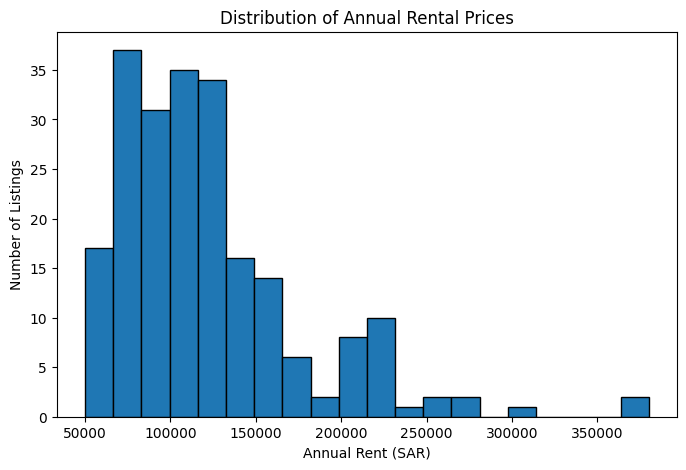

In [ ]:

plt.figure(figsize=(8, 5))
plt.hist(df['annual_rent_sar'], bins=20, edgecolor='black')

plt.title('Distribution of Annual Rental Prices')
plt.xlabel('Annual Rent (SAR)')
plt.ylabel('Number of Listings')

plt.show()

### Annual Rental Price Distribution

The annual rental prices are right-skewed. Most listings are between approximately 50,000 and 150,000 SAR per year, while fewer properties have much higher rental prices. This creates a long right tail in the distribution. The mean rent is also higher than the median, which supports this pattern.

### Property Area Distribution

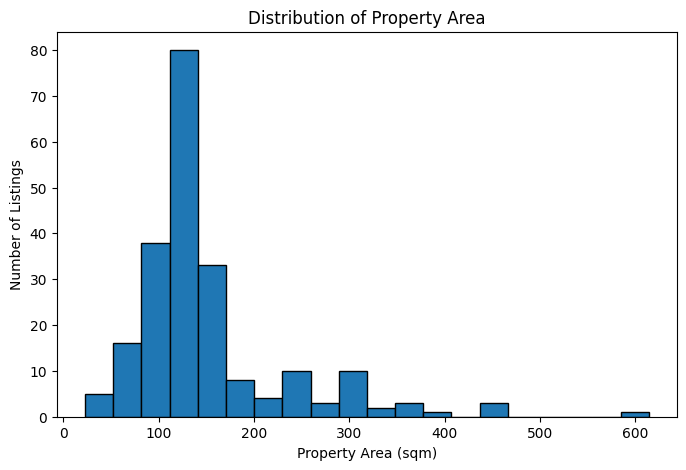

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['area_sqm'].dropna(), bins=20, edgecolor='black')

plt.title('Distribution of Property Area')
plt.xlabel('Property Area (sqm)')
plt.ylabel('Number of Listings')

plt.show()

### Interpretation of Property Area Distribution

The property area distribution is right-skewed. Most properties have smaller to medium-sized areas, while fewer properties have much larger areas. These larger properties create a long right tail in the distribution.

### Bedroom Distribution

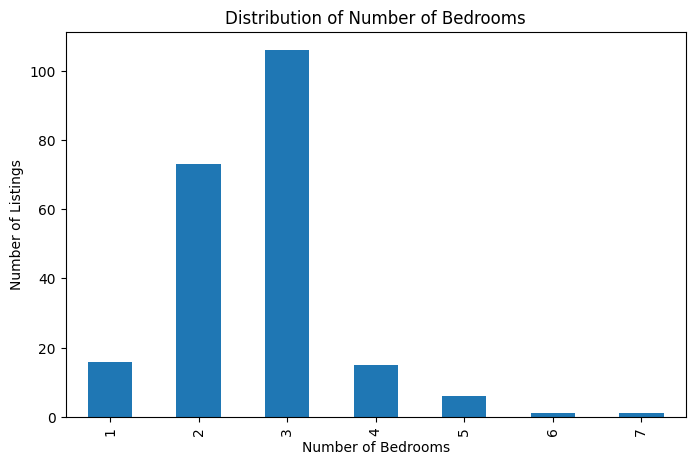

In [ ]:
plt.figure(figsize=(8,5))

df['bedrooms'].value_counts().sort_index().plot(kind='bar')

plt.title('Distribution of Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Number of Listings')

plt.show()

### Interpretation of Bedroom Distribution

Three-bedroom properties are the most common in the dataset, followed by two-bedroom properties. Properties with four or more bedrooms appear much less frequently, while six- and seven-bedroom properties are rare.

### Bathroom Distribution

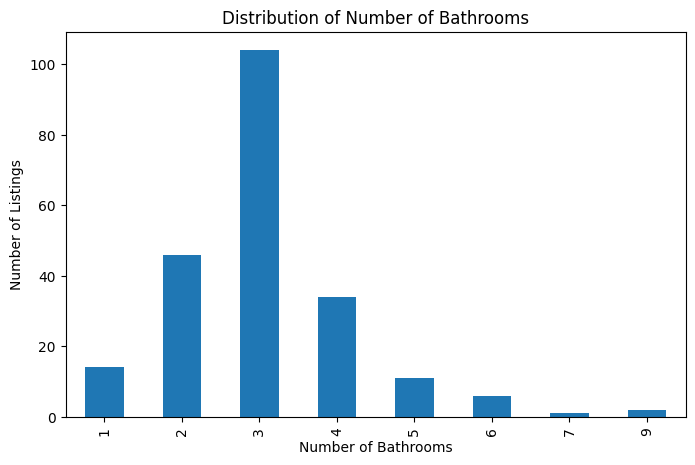

In [ ]:
plt.figure(figsize=(8,5))

df['bathrooms'].value_counts().sort_index().plot(kind='bar')

plt.title('Distribution of Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Number of Listings')

plt.show()

### Interpretation of Bathroom Distribution

Three-bathroom properties are the most common in the dataset, followed by properties with two and four bathrooms. Properties with five or more bathrooms appear much less frequently, while listings with seven or nine bathrooms are rare.

### Property Type Distribution

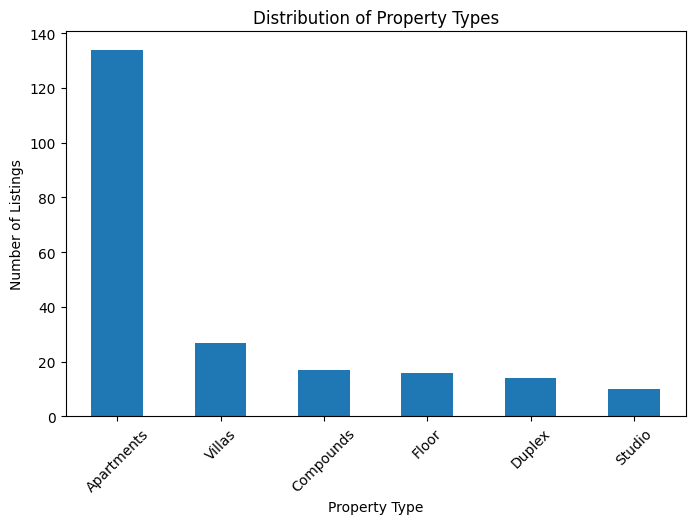

In [ ]:
plt.figure(figsize=(8,5))

df['property_type'].value_counts().plot(kind='bar')

plt.title('Distribution of Property Types')
plt.xlabel('Property Type')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)

plt.show()

### Interpretation Property Type Distribution

Apartments are the most common property type in the dataset, with 134 listings. Villas are the second most common with 27 listings, followed by compounds, floors, duplexes, and studios. This shows that the dataset contains more apartment listings compared with the other property types.

### Furnishing Distribution

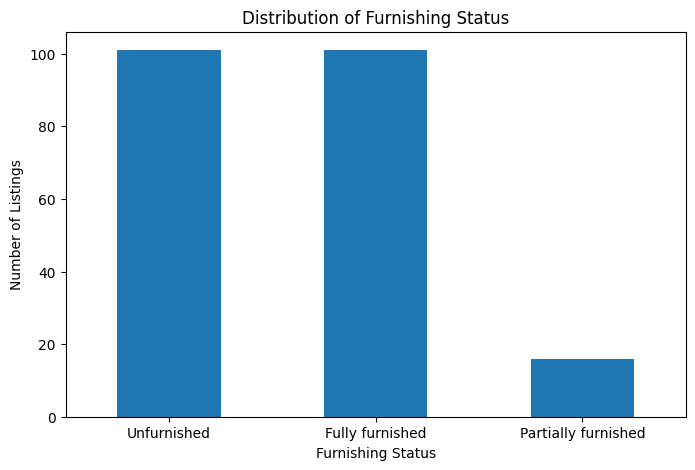

In [ ]:
plt.figure(figsize=(8,5))

df['furnishing'].value_counts().plot(kind='bar')

plt.title('Distribution of Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('Number of Listings')
plt.xticks(rotation=0)

plt.show()

### Interpretation of Furnishing Distribution
Fully furnished and unfurnished properties are equally common in the dataset, with 101 listings each. Partially furnished properties are much less common, with only 16 listings.

### Listing Status Distribution

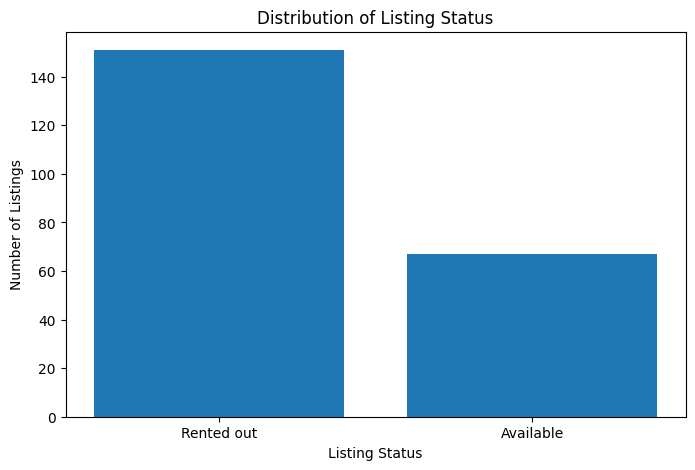

In [ ]:
status_counts = df['status'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(status_counts.index, status_counts.values)

plt.title('Distribution of Listing Status')
plt.xlabel('Listing Status')
plt.ylabel('Number of Listings')

plt.show()

### Listing Status Distribution

Most properties in the dataset are already rented out. There are 151 rented-out listings compared with 67 available listings. This shows that rented-out properties make up the majority of the dataset.

In [ ]:
# Save the cleaned and processed dataset
df.to_csv('cleaned_satel_riyadh_rentals.csv', index=False)

print("Cleaned dataset saved successfully.")
print("Final dataset shape:", df.shape)

Cleaned dataset saved successfully.
Final dataset shape: (218, 12)


### Data Cleaning Summary

The dataset was checked for missing values, duplicate records, data types, categorical values, and invalid numerical values. No duplicate property IDs were found. The neighborhood_ar column had 17 missing values, but the records were kept because the English neighborhood names were available. The created_at column was converted to datetime format. One property had an area of 0 square meters, so this value was changed to missing while keeping the rest of the listing. Inconsistent neighborhood names were also standardized. After cleaning, the final dataset contains 218 listings and 12 features.

## 17. Relationships, Correlations and Group Comparisons

In this section, we explore how annual rental prices vary across property types and neighborhoods. We also examine relationships between rental prices and numerical property characteristics.


### Load the Cleaned Dataset

We load the cleaned SATEL dataset uploaded to Colab for our analysis. We use the cleaned data prepared in the previous stage to explore relationships and compare rental prices across groups.



In [42]:
# Load the cleaned dataset
eda_df = pd.read_csv('cleaned_satel_riyadh_rentals.csv')

# Display the dataset dimensions
print("Number of rows:", eda_df.shape[0])
print("Number of columns:", eda_df.shape[1])

# Preview the first five rows
eda_df.head()

Number of rows: 218
Number of columns: 12


,property_id,neighborhood,neighborhood_ar,property_type,annual_rent_sar,area_sqm,bedrooms,bathrooms,furnishing,status,title_text,created_at
0,C0055,An Narjis,النرجس,Compounds,110000,139.0,3,4,Unfurnished,Available,Satel at Opal on Thoumamah Road - 3 Bedrooms A...,2026-04-06 14:15:09.408000+00:00
1,C0087,Al Olaya,العليا,Apartments,160000,112.0,2,3,Fully furnished,Available,Olaris More Than Just a Place to Live,2026-07-27 11:56:07.417000+00:00
2,A0177,An Narjis,النرجس,Compounds,140000,132.0,3,3,Fully furnished,Available,Satel at Opal — New Furnished & Unfurnished Ap...,2025-09-18 08:36:48.027000+00:00
3,C0052,Al Malaz,حي الملز,Compounds,73000,95.0,2,2,Fully furnished,Rented out,La Brise Community – Furnished 2 Beds with Bal...,2026-03-17 20:01:56.262000+00:00
4,C0084,An Nakheel,حي النخيل,Villas,370000,460.0,6,6,Partially furnished,Rented out,"Creative Community Where Comfort, Privacy, and...",2026-07-25 12:14:26.397000+00:00


## 18. Annual Rent by Property Type

We compare annual rental prices across property types to address our research question.

For each property type, we calculate the mean, median, and number of listings. The mean shows the average annual rent. The median is less affected by extreme prices and helps us interpret the mean. The count shows how many listings each comparison is based on.

In [43]:
# Group listings by property type and summarize annual rent
rent_by_type = eda_df.groupby('property_type')['annual_rent_sar'].agg(
    ['count', 'mean', 'median']
).round(2)

# Display the comparison table
rent_by_type

,count,mean,median
property_type,,,
Apartments,134,104626.87,105000.0
Compounds,17,114058.82,120000.0
Duplex,14,166785.64,144999.5
Floor,16,97687.50,90000.0
Studio,10,72700.00,67500.0
Villas,27,219629.63,220000.0
